In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, Input

In [2]:
data = np.load("windows_500_50.npz", allow_pickle=True)

X = data["X"]
y_env = data["y_env"]

encoder = LabelEncoder()
y = encoder.fit_transform(y_env)

X = X[..., np.newaxis]

print("Dataset shape:", X.shape)

Dataset shape: (3297, 500, 1)


In [3]:
def build_cnn(input_shape, num_classes):

    model = models.Sequential([

        layers.Conv1D(32,5,padding="same",activation="relu",input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(64,5,padding="same",activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(128,3,padding="same",activation="relu"),

        layers.GlobalAveragePooling1D(),

        layers.Dense(128,activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(num_classes,activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [4]:
def residual_block(x, filters):

    shortcut = x

    x = layers.Conv1D(filters,3,padding="same",activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(filters,3,padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters,1,padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


def build_resnet(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = layers.Conv1D(32,7,padding="same",activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = residual_block(x,32)
    x = residual_block(x,64)

    x = layers.MaxPooling1D(2)(x)

    x = residual_block(x,128)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128,activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes,activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [5]:
frames = [500, 1000]
overlaps = [0.4, 0.5]

models_to_test = ["CNN","ResNet"]

results = []

In [6]:
for model_name in models_to_test:

    for frame in frames:

        for overlap in overlaps:

            print("Running:", model_name, frame, overlap)

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, stratify=y, random_state=42
            )

            if model_name == "CNN":

                model = build_cnn(X_train.shape[1:], len(np.unique(y)))

            else:

                model = build_resnet(X_train.shape[1:], len(np.unique(y)))

            model.fit(
                X_train,
                y_train,
                epochs=20,
                batch_size=32,
                verbose=0
            )

            y_pred = model.predict(X_test)
            y_pred = np.argmax(y_pred, axis=1)

            acc = accuracy_score(y_test, y_pred)

            results.append({
                "Model":model_name,
                "Frame":frame,
                "Overlap":overlap,
                "Accuracy":acc
            })

Running: CNN 500 0.4


C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Running: CNN 500 0.5


C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Running: CNN 1000 0.4


C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Running: CNN 1000 0.5


C:\Users\Lenovo\miniconda3\envs\iot_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Running: ResNet 500 0.4
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Running: ResNet 500 0.5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
Running: ResNet 1000 0.4
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step
Running: ResNet 1000 0.5
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


In [7]:
results_df = pd.DataFrame(results)

results_df

,Model,Frame,Overlap,Accuracy
0,CNN,500,0.4,0.606061
1,CNN,500,0.5,0.555152
2,CNN,1000,0.4,0.550303
3,CNN,1000,0.5,0.718788
4,ResNet,500,0.4,0.398788
5,ResNet,500,0.5,0.368485
6,ResNet,1000,0.4,0.623030
7,ResNet,1000,0.5,0.640000


In [8]:
results_df = pd.DataFrame(results)

results_df

,Model,Frame,Overlap,Accuracy
0,CNN,500,0.4,0.606061
1,CNN,500,0.5,0.555152
2,CNN,1000,0.4,0.550303
3,CNN,1000,0.5,0.718788
4,ResNet,500,0.4,0.398788
5,ResNet,500,0.5,0.368485
6,ResNet,1000,0.4,0.623030
7,ResNet,1000,0.5,0.640000


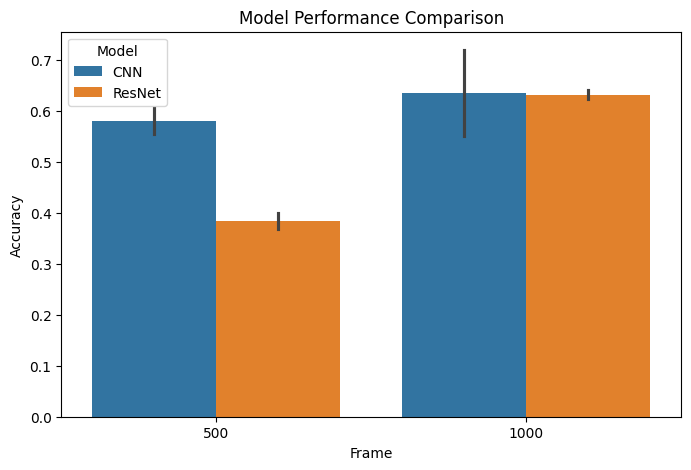

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Frame",
    y="Accuracy",
    hue="Model",
    data=results_df
)

plt.title("Model Performance Comparison")

plt.show()

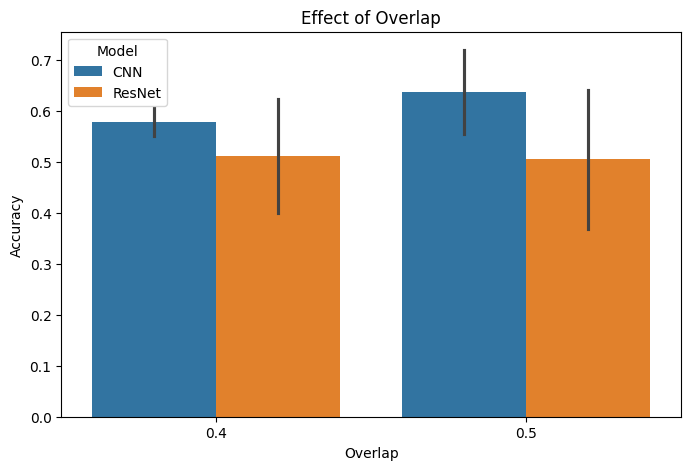

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Overlap",
    y="Accuracy",
    hue="Model",
    data=results_df
)

plt.title("Effect of Overlap")

plt.show()

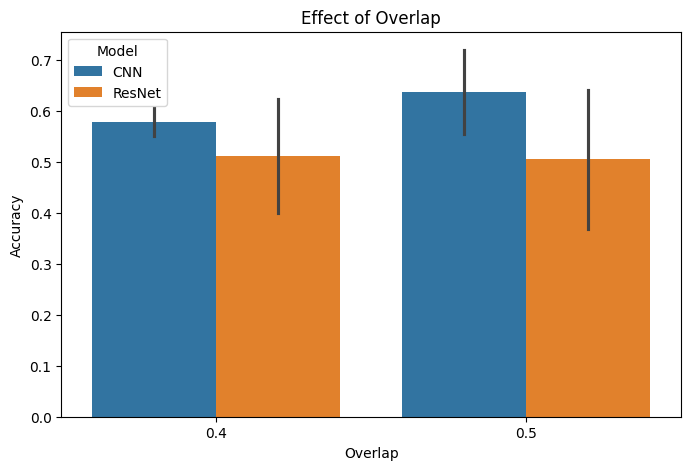

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Overlap",
    y="Accuracy",
    hue="Model",
    data=results_df
)

plt.title("Effect of Overlap")

plt.show()

In [12]:
results_df.to_csv("experiment_results.csv", index=False)